# 05 — Grad-CAM (Interpretasi Model)

Grad-CAM *(Gradient-weighted Class Activation Mapping)* memvisualisasikan **area penting** yang menjadi fokus model MobileNetV2 saat mengklasifikasi citra bencana.

Berguna untuk:
- Membuktikan model belajar fitur relevan (bukan artifact)
- Analisis kualitatif prediksi
- Bagian paper: *Interpretabilitas Model*

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from src.config import TEST_DIR, RESULTS_DIR, CLASSES
from src.evaluate import load_model
from src.gradcam import (
    make_gradcam_heatmap, overlay_gradcam,
    visualize_gradcam, batch_gradcam_by_class,
    LAST_CONV_LAYER
)

GRADCAM_DIR = os.path.join(RESULTS_DIR, 'gradcam')
os.makedirs(GRADCAM_DIR, exist_ok=True)

model = load_model('../models/final_model.keras')
print('Model loaded. Last conv layer:', LAST_CONV_LAYER)

✅ Config loaded successfully!
📁 RAW_DIR: C:\Users\ACER\Documents\ANALIS CITRA.py\dataset\raw\Comprehensive Disaster Dataset(CDD)
📁 TRAIN_DIR: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\dataset\processed\train
📁 VAL_DIR: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\dataset\processed\val
📁 TEST_DIR: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\dataset\processed\test
📊 Classes: ['Damaged_Infrastructure', 'Fire_Disaster', 'Human_Damage', 'Land_Disaster', 'Non_Damage', 'Water_Disaster']
📐 Input Shape: (224, 224, 3)
🔄 FREEZE_EPOCHS: 10
🔄 FINETUNE_EPOCHS: 10
[loaded] ../models/final_model.keras
Model loaded. Last conv layer: Conv_1_bn


## 1. Grad-CAM — Satu Gambar

Gambar: c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\dataset\processed\test\Non_Damage\06_04_1127.png


c:\Users\ACER\Documents\VS CODE DATA py\.venv\lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\sample_gradcam.png


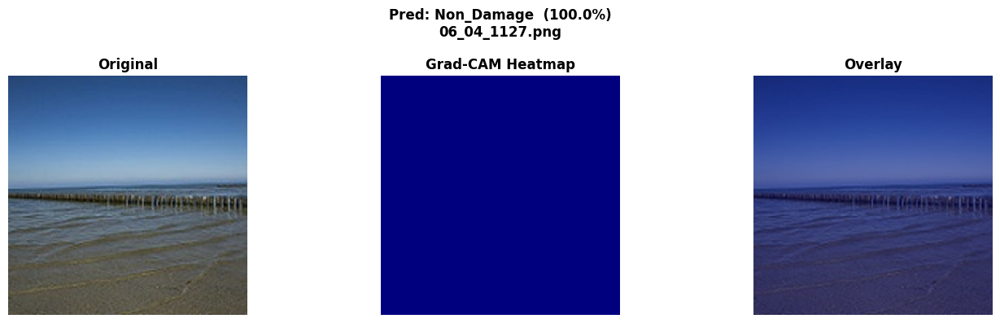

In [2]:
import glob, random

# Pilih gambar acak dari test set
all_test_imgs = glob.glob(os.path.join(TEST_DIR, '**', '*.png'), recursive=True)
sample_img    = random.choice(all_test_imgs)
print('Gambar:', sample_img)

pred_cls, conf, heatmap = visualize_gradcam(
    sample_img, model, CLASSES,
    save_path=os.path.join(GRADCAM_DIR, 'sample_gradcam.png')
)

## 2. Grad-CAM — Per Kelas (3 contoh/kelas)

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\Damaged_Infrastructure_01_gradcam.png


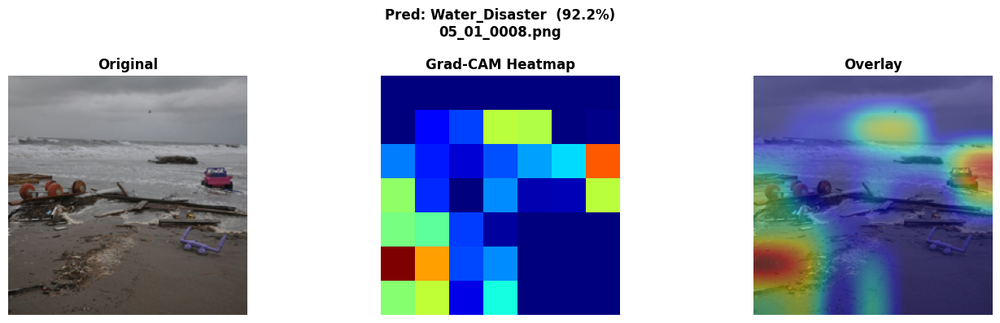

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\Damaged_Infrastructure_02_gradcam.png


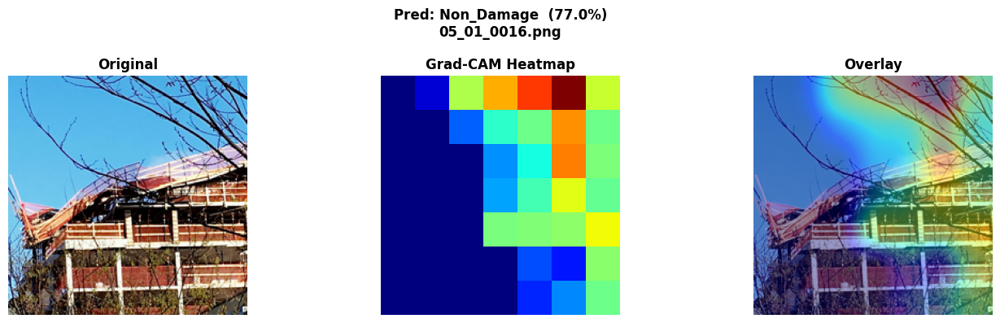

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\Damaged_Infrastructure_03_gradcam.png


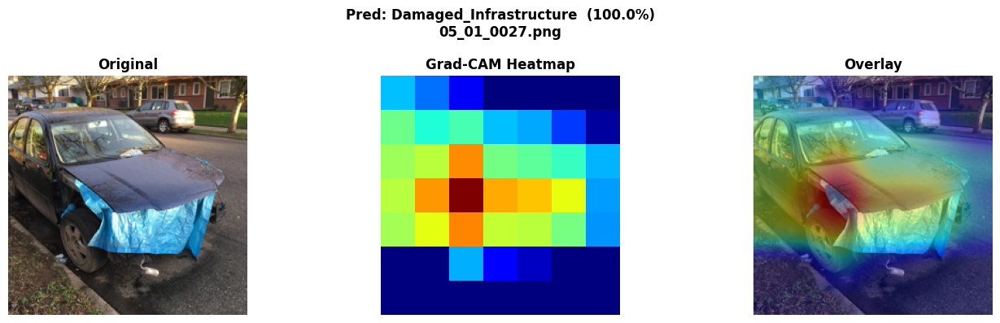

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\Fire_Disaster_01_gradcam.png


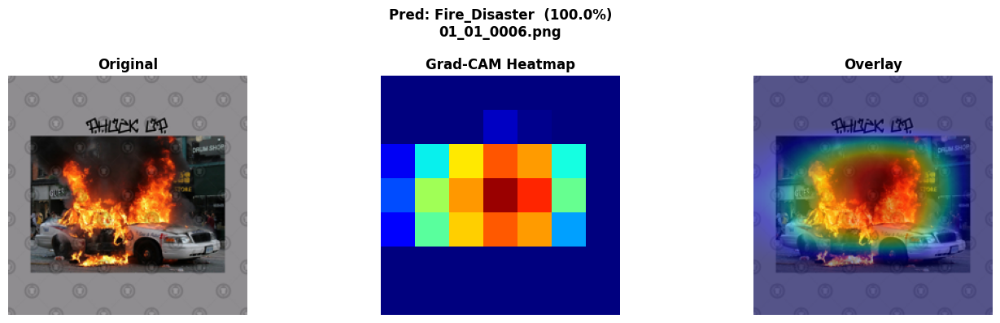

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\Fire_Disaster_02_gradcam.png


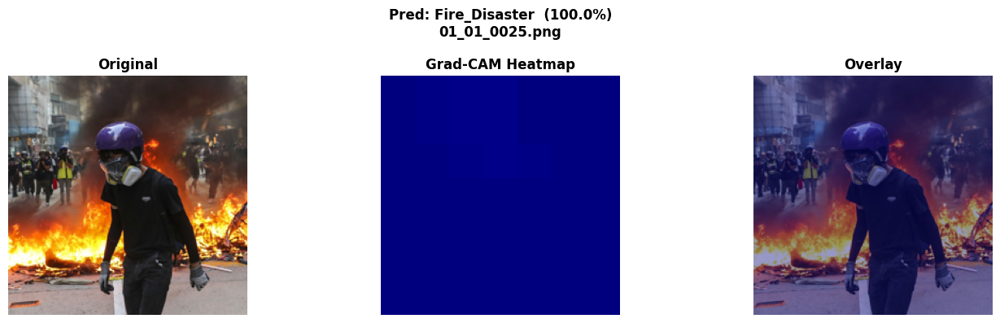

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\Fire_Disaster_03_gradcam.png


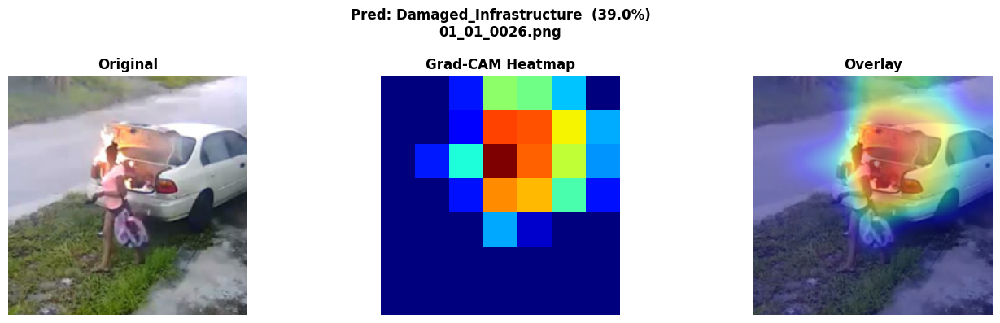

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\Human_Damage_01_gradcam.png


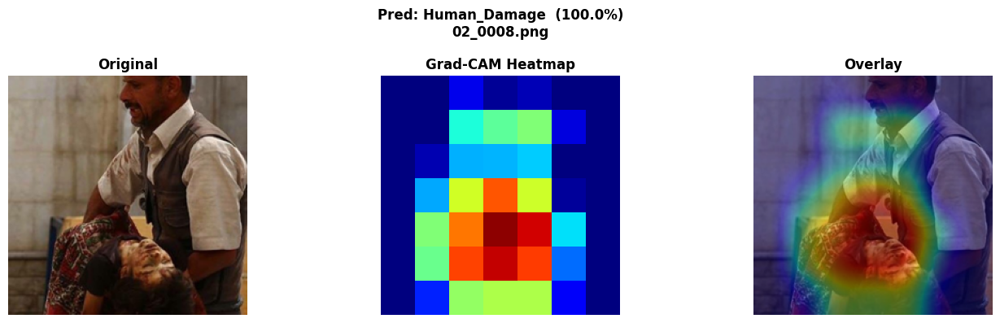

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\Human_Damage_02_gradcam.png


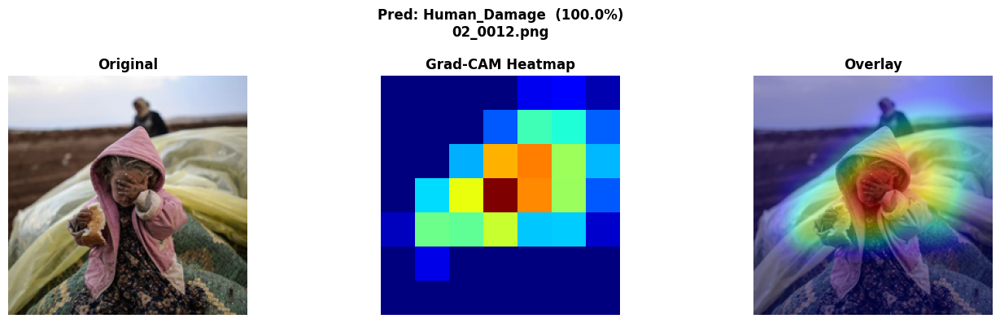

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\Human_Damage_03_gradcam.png


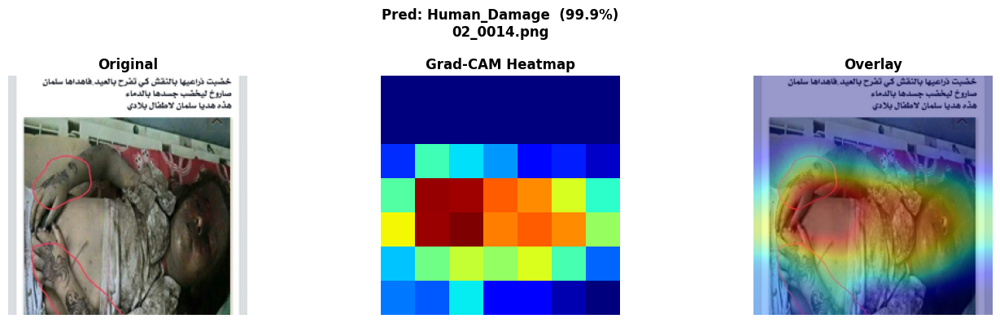

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\Land_Disaster_01_gradcam.png


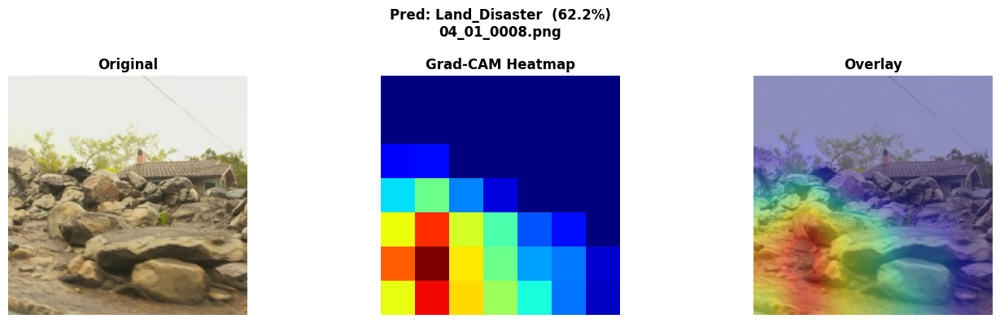

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\Land_Disaster_02_gradcam.png


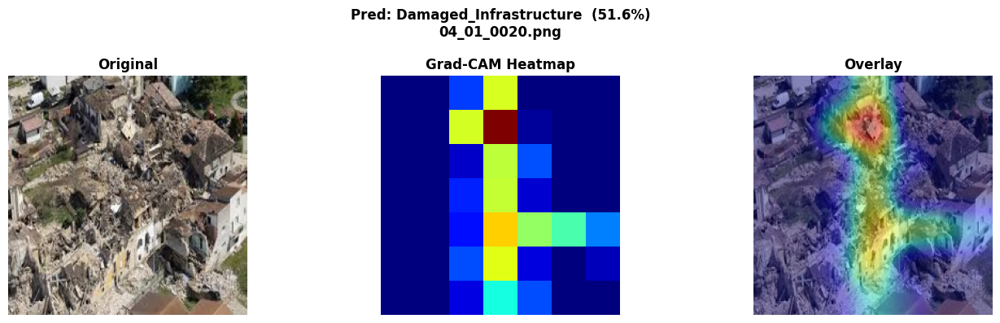

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\Land_Disaster_03_gradcam.png


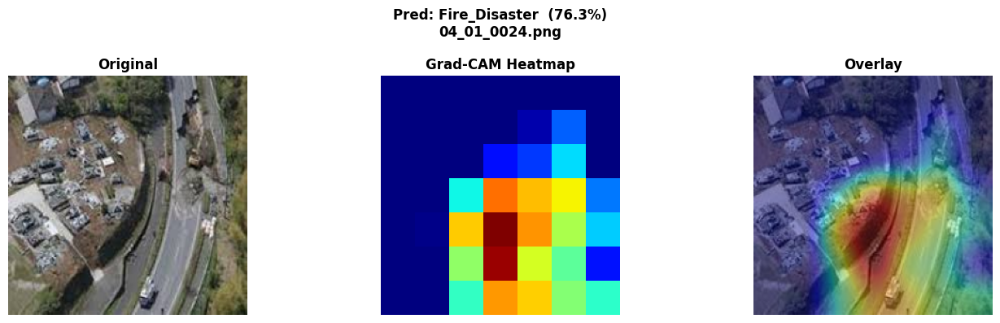

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\Non_Damage_01_gradcam.png


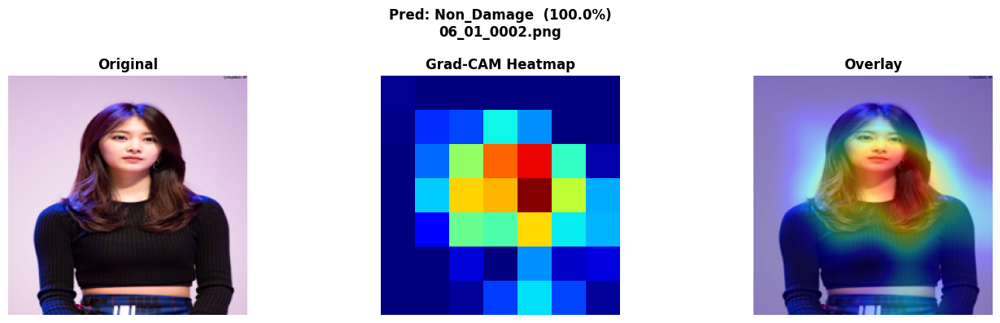

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\Non_Damage_02_gradcam.png


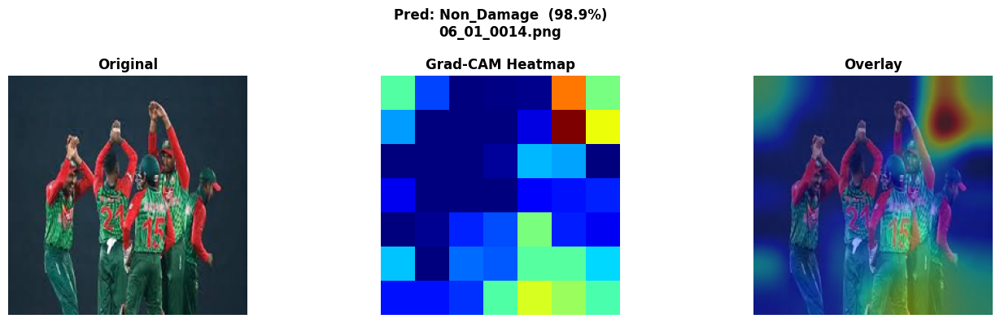

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\Non_Damage_03_gradcam.png


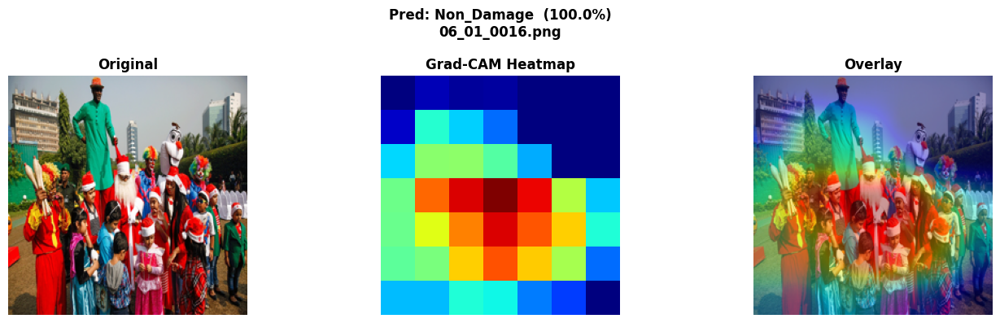

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\Water_Disaster_01_gradcam.png


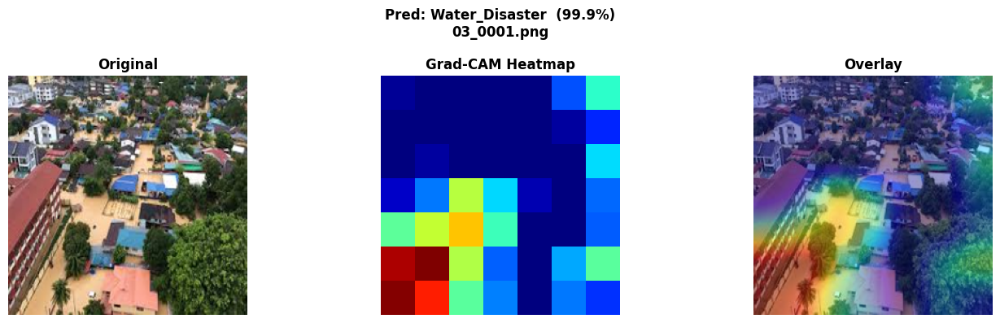

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\Water_Disaster_02_gradcam.png


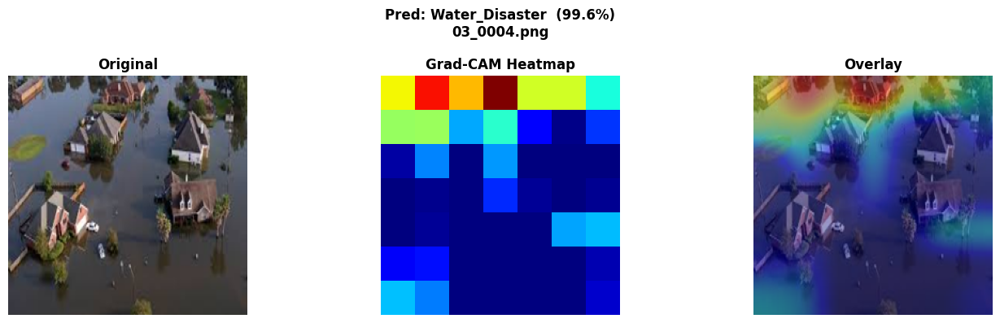

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\Water_Disaster_03_gradcam.png


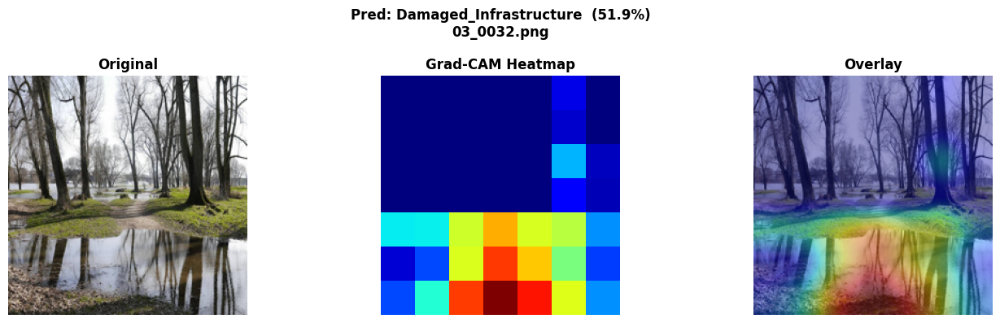

✅ Grad-CAM batch selesai


In [3]:
batch_gradcam_by_class(
    test_dir    = TEST_DIR,
    model       = model,
    class_names = CLASSES,
    n_per_class = 3,
    save_dir    = GRADCAM_DIR
)
print('✅ Grad-CAM batch selesai')

## 3. Grad-CAM Grid — Semua Kelas dalam Satu Figure

[saved] c:\Users\ACER\Documents\ANALIS CITRA.py\Disaster-MobileNetV2\results\gradcam\gradcam_grid.png


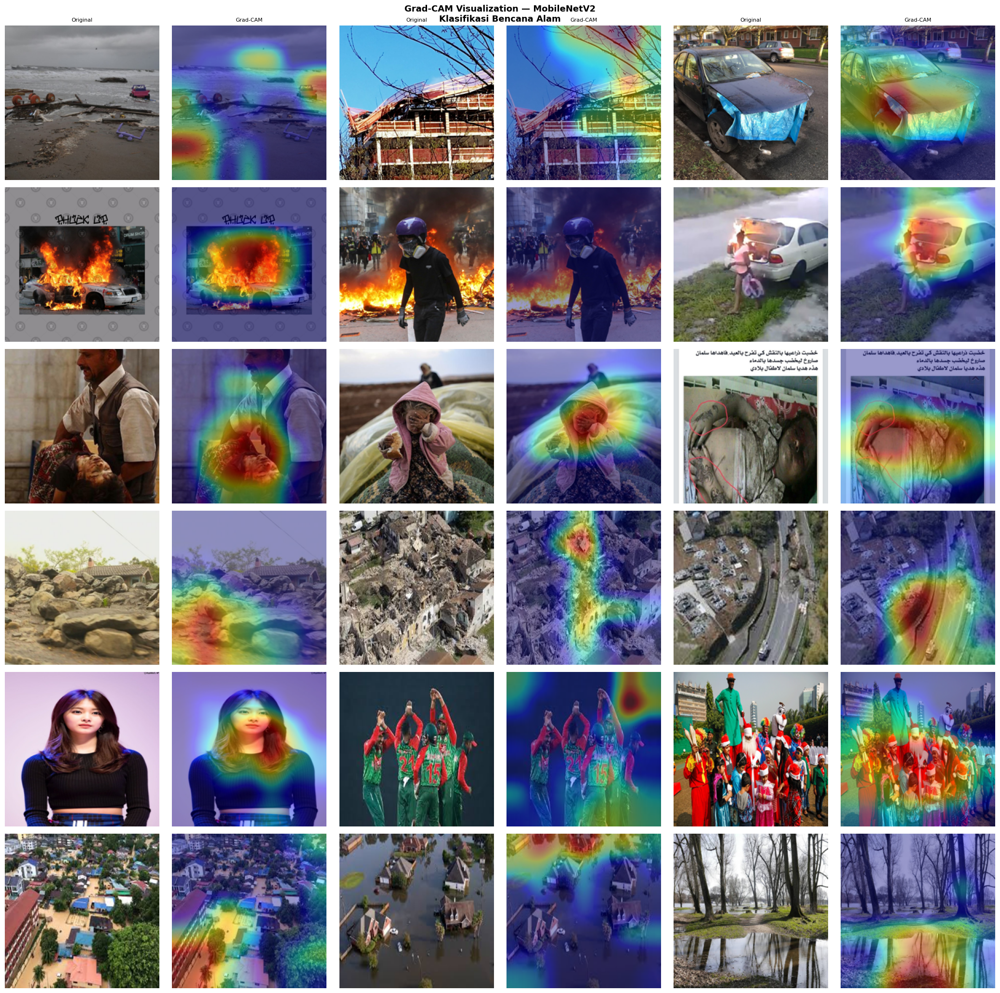

In [4]:
from src.preprocessing import load_and_preprocess
from PIL import Image
from src.config import IMAGE_SIZE

n_cls  = len(CLASSES)
n_cols = 3   # gambar per kelas
fig, axes = plt.subplots(n_cls, n_cols * 2, figsize=(n_cols*2*3.5, n_cls*3.5))

for r, cls in enumerate(CLASSES):
    cls_dir = os.path.join(TEST_DIR, cls)
    if not os.path.isdir(cls_dir):
        continue
    imgs = [os.path.join(cls_dir, f) for f in os.listdir(cls_dir)
            if f.lower().endswith(('.png','.jpg','.jpeg'))][:n_cols]
    
    for c, img_path in enumerate(imgs):
        orig     = np.array(Image.open(img_path).convert('RGB').resize(IMAGE_SIZE))
        arr      = load_and_preprocess(img_path)[np.newaxis]
        heatmap  = make_gradcam_heatmap(arr, model)
        overlay  = overlay_gradcam(orig, heatmap)
        
        axes[r, c*2].imshow(orig)
        axes[r, c*2].set_title('Original' if r == 0 else '', fontsize=8)
        axes[r, c*2].axis('off')
        
        axes[r, c*2+1].imshow(overlay)
        axes[r, c*2+1].set_title('Grad-CAM' if r == 0 else '', fontsize=8)
        axes[r, c*2+1].axis('off')
    
    axes[r, 0].set_ylabel(cls, fontsize=10, fontweight='bold',
                          rotation=0, labelpad=60, va='center')

plt.suptitle('Grad-CAM Visualization — MobileNetV2\nKlasifikasi Bencana Alam',
             fontsize=13, fontweight='bold')
plt.tight_layout()
save_grid = os.path.join(GRADCAM_DIR, 'gradcam_grid.png')
plt.savefig(save_grid, dpi=120, bbox_inches='tight')
print(f'[saved] {save_grid}')
plt.show()

## 4. Analisis Grad-CAM

Grad-CAM menunjukkan bahwa model MobileNetV2 berfokus pada:
- **Flood**: area genangan air, warna coklat/biru pada permukaan
- **Earthquake**: retakan, puing-puing, struktur yang runtuh
- **Wildfire**: area berwarna oranye/merah (api), asap
- **Landslide**: longsor tanah, perubahan kontur lereng
- **Cyclone**: pola spiral awan, pusat badai
- **Non_Damage**: bangunan utuh, hutan hijau, laut tenang

> Ini membuktikan model **tidak** hanya menghafal, tapi belajar fitur visual yang **relevan secara semantik**.

---
### ✅ Grad-CAM selesai. Lanjut ke `06_Testing.ipynb`